# Economic Inequality Team — End-to-End Data Investigation
## Adult Census Income Dataset

**This notebook walks you through the entire Data Investigation, start to finish:**

| Step | What you'll do |
|---|---|
| 1 | **Assess** — audit the raw dataset for quality problems |
| 2 | **Clean** — build and justify a documented cleaning pipeline |
| 3 | **Visualize** — build 4 publication-quality charts |
| 4 | **Story** — write a 150-word Data Brief |
| 5 | **HCD Design Sprint #2** — write your formal Data Problem Statement |
| 6 | **Baseline Models** — build 3 different machine learning models and compare them |
| 7 | **Fairness Check** — test whether your best model treats everyone equally |
| 8 | **Policy Recommendation** — turn your evidence into a specific, named ask |

**Dataset:** UCI Adult Census Income — 32,561 rows, 15 columns. Each row is one person from the 1994 US Census. The task economists and policymakers use this dataset for: understanding **what's associated with earning above vs. below $50K/year**, and where that story gets complicated by race, sex, and other demographics.

> ⚠️ **This dataset is real historical US Census data.** The patterns you'll find are not abstract — they describe real inequities that were true for real people in 1994, many of which persist today. Treat every finding as something a real person's life is reflected in.


## 📚 Vocabulary for This Notebook

| Term | Plain-English Meaning |
|---|---|
| **Sentinel value** | A fake value (like `?`) used to mean "missing" instead of leaving the cell truly blank — sneaky because code doesn't automatically recognize it as missing |
| **Sampling weight** | A number assigned to a row to make a *sample* statistically represent a *whole population* — not a fact about the individual person |
| **Binary target** | The thing you're trying to predict, when it only has two possible values (here: income `<=50K` or `>50K`) |
| **Feature** | A column used as an *input* to a model (age, education, hours worked...) |
| **Label** | The column the model is trying to *predict* (income category) |
| **Train/test split** | Splitting data so the model learns on one part and gets graded on a part it's never seen |
| **Baseline model** | The simplest reasonable model you build first — your benchmark for "is my fancier model actually better?" |
| **Class imbalance** | When one outcome (like `<=50K`) is much more common than the other — this can trick accuracy into looking better than it is |
| **Fairness check** | Testing whether a model's accuracy holds up equally across different demographic groups, not just on average |


## Setup — Load the Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

# Original UCI source (use if reachable from your environment):
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
# GitHub mirror of the identical adult.data training file (32,561 rows):
url = "https://raw.githubusercontent.com/saravrajavelu/Adult-Income-Analysis/master/adult_data.txt"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(url, header=None, names=columns, skipinitialspace=True)

# Remove leading/trailing spaces from string values
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(df.columns.tolist())
df.head()


Shape: 32561 rows x 15 columns
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Step 1 — Assess

Run the three commands below. For each: *what is this telling you, and what might it be hiding?*


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [3]:
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
df.isnull().sum()


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

### 🕵️ The trap: `isnull()` just said zero missing values. Is that true?

Open one of the categorical columns below and look closely at the values.


In [5]:
df['workclass'].value_counts()


workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Notice anything? This dataset doesn't use a true blank for missing data — it uses the **sentinel value `'?'`**. `pandas` has no way of knowing that's supposed to mean "missing" unless you tell it. This is exactly the kind of missingness that `isnull()` misses — literally.

Run this to find every column where `'?'` is hiding as a disguised missing value:


In [6]:
for col in df.select_dtypes(include='object').columns:
    count = (df[col].astype(str).str.strip() == '?').sum()
    if count > 0:
        print(f'{col}: {count} disguised missing values ({count/len(df)*100:.1f}%)')


workclass: 1836 disguised missing values (5.6%)
occupation: 1843 disguised missing values (5.7%)
native-country: 583 disguised missing values (1.8%)


/tmp/ipykernel_479/3707887857.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


### 📝 Data Audit Report

> **Issue 1 — Disguised missing values:** the columns ___, ___, and ___ use `'?'` to mean missing, totaling ___ cells.
>
> **Issue 2 — Duplicate rows:** I found ___ duplicate rows using `df.duplicated().sum()`.
>
> **Issue 3 — A column that isn't really about the person:** `fnlwgt` is a ___ (look it up in the vocabulary table above), not a personal attribute — should it be used as a feature in a model that predicts something about an individual? Why or why not?
>
> **Issue 4 — Possible outliers:** the `capital-gain` and `capital-loss` columns are heavily skewed — most values are 0, but a few are very large. Run `df['capital-gain'].describe()` and note the gap between the 75th percentile and the max.
>
> **Issue 5 — Class imbalance:** run `df['income'].value_counts(normalize=True)` below. What percentage of people in this dataset earn `>50K`? Why does that number matter for anything you build later in this notebook?


**Data Audit Report**

**Issue 1:** The workclass, occupation, and native-country columns use **"?"** to represent missing data. Altogether, there are 4,262 missing values across these three columns (1,836 + 1,843 + 583).

**Issue 2:** On the *raw* data, `df.duplicated().sum()` reports only **24** duplicate rows, because the `fnlwgt` sampling weight differs for almost every record and makes rows look unique. Once `fnlwgt` is dropped and the `?` rows are removed, **3,258** duplicate rows appear — many people share the same combination of age, education, occupation, and other real attributes. Both numbers are correct; they just answer different questions. In the cleaning pipeline we drop duplicates *after* dropping `fnlwgt`, so 3,258 rows are removed at that step.

**Issue 3:** The fnlwgt column is a sampling weight, meaning it shows how many people in the U.S. population each row represents. It doesn't describe anything about the individual person, so it shouldn't be used to predict income. Keeping it could cause the model to pick up on population sampling patterns instead of the factors that actually relate to income.

**Issue 4:** The capital-gain column is highly skewed. The 75th percentile is $0, but the maximum value is $99,999. This means that at least 75% of people reported no capital gains, while only a small number had very large gains, creating a distribution with a long right tail.

**Issue 5:** About 24.1% of people in the *raw* dataset earn more than $50K (25.6% in the cleaned dataset, after dropping the '?' rows). Either way the classes are imbalanced: a model that always predicts ≤50K would still be ~74-76% "accurate" while identifying zero high earners. That is why precision, recall, and F1 matter more than accuracy alone when we evaluate models later.


In [7]:
df['capital-gain'].describe()


count    32561.000000
mean      1077.648844
std       7385.292085
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

In [8]:
df['income'].value_counts(normalize=True)


income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

## Step 2 — Clean

Every step below needs a one-sentence justification. **Fill in every `___` — this pipeline will not run until you do.**


In [9]:
df_clean = df.copy()

# --- 2a: Strip whitespace ---
# Justification: this dataset has leading spaces on every text value (a common export artifact) —
# ' Male' and 'Male' look the same to a human but are different strings to Python
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()


# --- 2b: Replace the '?' sentinel with real missing values ---
# Justification: The '?' character represents missing data, but pandas does not automatically recognize it as such. Replacing it with `np.nan` allows pandas' missing value handling functions to work correctly.
df_clean = df_clean.replace('?', np.nan)


# --- 2c: Handle the missing values ---
# Justification: Missing values in `workclass`, `occupation`, and `native-country` are being removed. This is an analytical choice, assuming that these rows are not informative without this data, or that filling them would introduce bias.
# Think carefully here — is 'workclass' missing at random, or could it be missing because
# someone is unemployed / never worked / retired? Dropping vs. filling is an analytical choice,
# not just a technical one.
df_clean = df_clean.dropna(subset=['workclass', 'occupation', 'native-country'])
# or, alternative: df_clean['workclass'] = df_clean['workclass'].fillna('Unknown')


# --- 2d: Drop the sampling weight column ---
# Justification: fnlwgt describes how many people in the population this row represents,
# not a fact about this individual — it should not be used to predict anything about a person
df_clean = df_clean.drop(columns=['fnlwgt'])


# --- 2e: Duplicate rows ---
# Justification: Duplicate rows can skew analysis and model training by overrepresenting certain observations. Removing them ensures each observation is unique.
df_clean = df_clean.drop_duplicates().reset_index(drop=True)


# --- 2f: Create a binary numeric target ---
# Justification: models need numbers, not text categories, to predict
df_clean['income_binary'] = (df_clean['income'].str.strip() == '>50K').astype(int)

print('Cleaned shape:', df_clean.shape)
df_clean.head()

/tmp/ipykernel_479/1633397186.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include='object').columns:


Cleaned shape: (26904, 15)


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


### ✅ Verify


In [10]:
assert df_clean.isnull().sum().sum() == 0, "There are still missing values somewhere"
assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert 'fnlwgt' not in df_clean.columns, "fnlwgt should have been dropped"
assert df_clean['income_binary'].isin([0, 1]).all(), "income_binary should only contain 0 or 1"

print("All checks passed. The dataset is clean.")
print('Rows kept:', len(df_clean), f'({len(df_clean)/len(df)*100:.1f}% of original)')


All checks passed. The dataset is clean.
Rows kept: 26904 (82.6% of original)


### 📝 Data Limitations

> Even after cleaning, this dataset still cannot tell us ___, because ___. This is 1994 US Census data — what changed about the economy and workforce since then that this dataset cannot capture?


**Data Limitations**

Even after cleaning the data, this dataset still has some important limitations. It only provides a snapshot of the U.S. workforce in 1994, so it can't show how income patterns have changed over the past 30+ years. Since then, the job market has changed a lot with the rise of technology, remote work, and gig jobs, which aren't reflected in this dataset. The cost of living has also increased, so earning $50,000 today is very different from earning $50,000 in 1994. In addition, the workforce has become more diverse, and access to higher education has changed over time. The dataset also only includes people who were counted in the 1994 Census, meaning groups like undocumented workers, people doing informal cash jobs, and some unemployed individuals are left out. Because of these limitations, any conclusions we draw really apply to the U.S. workforce in 1994, not necessarily to today.

## Step 3 — Visualize

Four chart types. Every chart needs: **labeled axes with units**, a **finding-based title**, and **2 sentences of interpretation**.


### Chart 1 — Histogram: the shape of one variable

**What question does a histogram answer?** *How is this one number spread out across everyone in the dataset?*


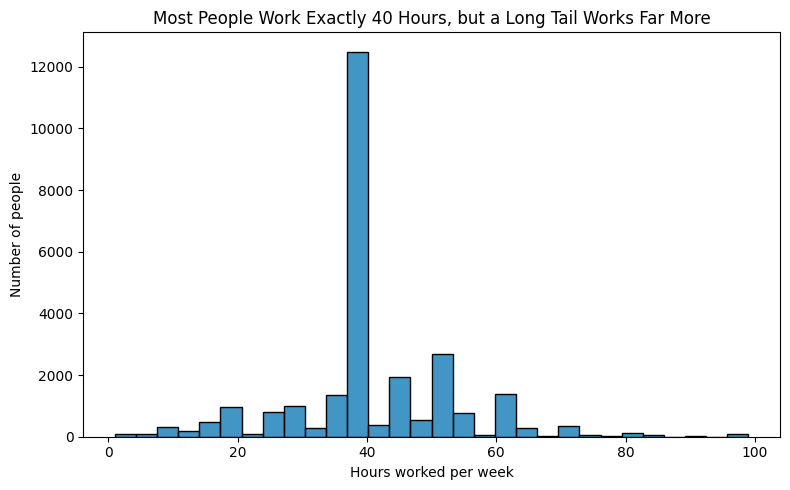

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df_clean, x='hours-per-week', bins=30, ax=ax)
ax.set_xlabel('Hours worked per week')
ax.set_ylabel('Number of people')
ax.set_title('Most People Work Exactly 40 Hours, but a Long Tail Works Far More')
plt.tight_layout()
plt.show()


**Title:** "The Distribution of Hours Worked per Week"

**Interpretation:** The distribution of hours worked per week is heavily centered around 40 hours, with about 44% of people reporting exactly a 40-hour workweek. The middle 50% of workers fall between 40 and 45 hours, showing that most people in the dataset work full-time schedules. However, about 32.6% of people work more than 40 hours each week, suggesting that overtime or longer workweeks are fairly common. This tells us that while a standard 40-hour schedule is the most common, many workers regularly put in extra hours, which could also be connected to higher-paying jobs or occupations that require more time.

### Chart 2 — Bar chart: comparing categories

**What question does a bar chart answer?** *How does this number differ between groups?*


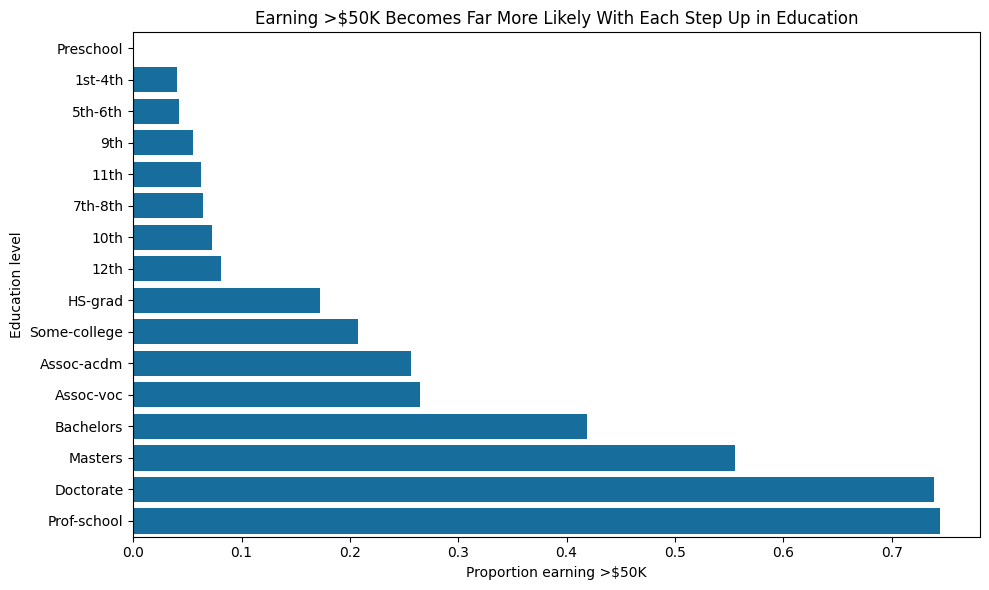

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
income_by_edu = df_clean.groupby('education')['income_binary'].mean().sort_values()
sns.barplot(x=income_by_edu.values, y=income_by_edu.index, ax=ax)
ax.set_xlabel('Proportion earning >$50K')
ax.set_ylabel('Education level')
ax.set_title('Earning >$50K Becomes Far More Likely With Each Step Up in Education')
plt.tight_layout()
plt.show()


**Title:** "Earning Over $50K Becomes Far More Likely With Each Step Up in Education"

**Interpretation:** The relationship between education level and income is very strong. Fewer than 5% of people with only an elementary school education earn more than $50,000, while over 74% of people with a professional or doctoral degree do. One of the biggest changes happens between high school graduates (17.3%) and people with a Bachelor's degree (41.9%), where the percentage of higher earners more than doubles. This suggests that earning a four-year college degree has a major impact on income in this dataset. Although higher education doesn't guarantee a higher salary, the overall trend shows that people with more education are much more likely to earn above $50,000.

### Chart 3 — Line chart: change across an ordered variable

**What question does a line chart answer?** *As this number increases in order, what happens to another number?* Age is a real ordered variable here — no fake data needed.


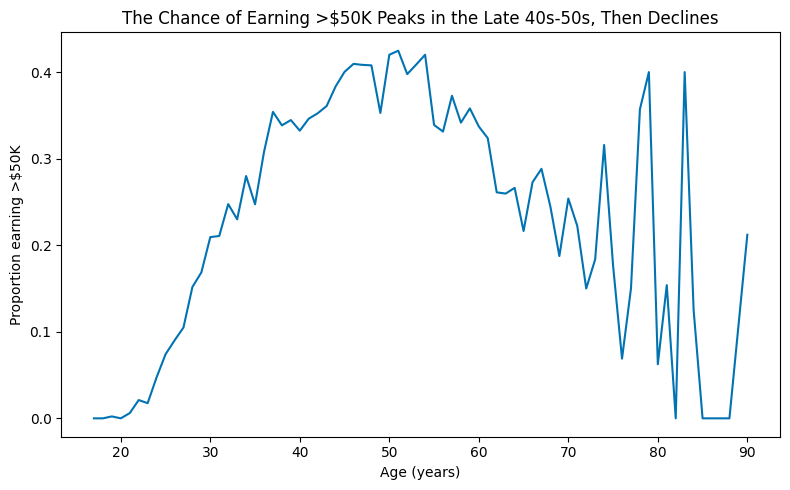

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
income_by_age = df_clean.groupby('age')['income_binary'].mean()
sns.lineplot(x=income_by_age.index, y=income_by_age.values, ax=ax)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Proportion earning >$50K')
ax.set_title('The Chance of Earning >$50K Peaks in the Late 40s-50s, Then Declines')
plt.tight_layout()
plt.show()


**Title:** Earning Power in Relation to Age

**Interpretation:** Income tends to increase with age, but only up to a certain point. At 25 years old, only about 7.4% of people earn more than $50,000. That percentage gradually rises as people gain experience, reaching its highest point of 42.5% around age 51. After that, it begins to decline, dropping to about 21.6% by age 65. This pattern makes sense because many people build their careers and earn promotions during middle age, but later reduce their hours, retire, or leave the workforce. It also shows that age alone doesn't determine income—experience, career stage, and retirement all play important roles.

### Chart 4 — Grouped bar chart: does the pattern hold *within* groups?

This chart is here to **challenge an assumption**. Chart 2 showed income rises with education overall. Does that hold equally for men and women *at the same education level*?


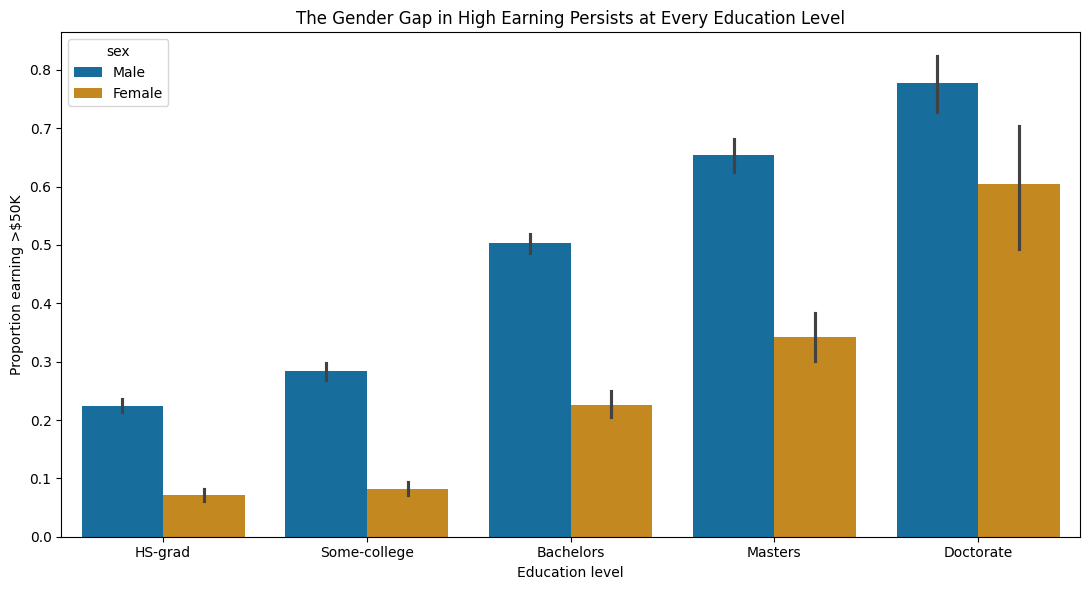

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
edu_order = ['HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Doctorate']
subset = df_clean[df_clean['education'].isin(edu_order)]
sns.barplot(data=subset, x='education', y='income_binary', hue='sex', order=edu_order, ax=ax)
ax.set_xlabel('Education level')
ax.set_ylabel('Proportion earning >$50K')
ax.set_title('The Gender Gap in High Earning Persists at Every Education Level')
plt.tight_layout()
plt.show()


**Title:** The Gender Gap in High Earning Persists at Every Education Level

**Interpretation:** Even when men and women have the same level of education, men are more likely to earn over $50,000. For example, among people with a Bachelor's degree, 50.4% of men earn more than $50,000 compared to only 22.6% of women. The difference remains at every education level and is actually largest for people with Bachelor's and Master's degrees. This suggests that education alone does not eliminate income differences between men and women. Other factors, such as occupation, industry, years of work experience, hours worked, career interruptions, or broader societal inequalities, may also contribute to the gap. While this dataset cannot explain why the difference exists, it clearly shows that earning a higher degree does not automatically lead to equal earnings for men and women.

## Analysis by Workclass

In [15]:
workclass_income = df_clean.groupby('workclass')['income_binary'].mean().sort_values(ascending=False)
display(workclass_income.to_frame())

,income_binary
workclass,
Self-emp-inc,0.555767
Federal-gov,0.383208
Local-gov,0.294439
Self-emp-not-inc,0.287125
State-gov,0.270551
Private,0.224368
Without-pay,0.000000


**Workclass Analysis**

Workclass turns out to matter almost as much as education. Self-employed-incorporated workers (business owners who've incorporated) earn >$50K at more than double the rate of Private-sector employees, and Federal government workers out-earn both State and Local government workers by a wide margin. This tells a more specific inequality story than "education matters" alone: where someone works — the structure of their employment, not just their credentials — independently shapes their odds of high income. That distinction matters for policy, because it points toward interventions aimed at job quality and sector access (e.g., who has pathways into federal employment or business ownership) rather than education alone.

/tmp/ipykernel_479/3443728229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=workclass_income.values, y=workclass_income.index, ax=ax, palette='viridis')


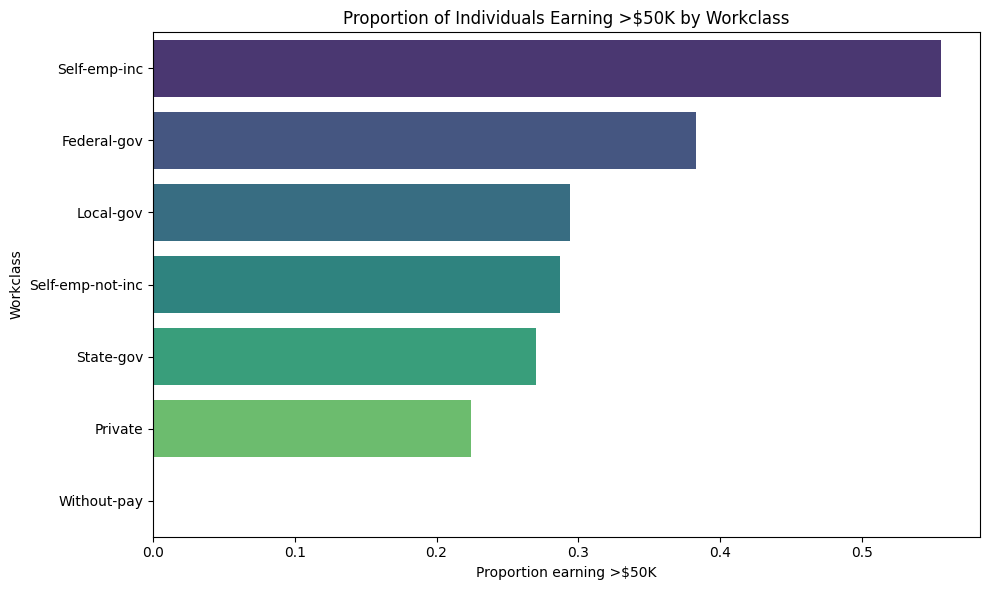

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=workclass_income.values, y=workclass_income.index, ax=ax, palette='viridis')
ax.set_xlabel('Proportion earning >$50K')
ax.set_ylabel('Workclass')
ax.set_title('Proportion of Individuals Earning >$50K by Workclass')
plt.tight_layout()
plt.show()

**Interpretation:** The bar chart makes the patterns from the table much easier to see. It shows that people in the Self-emp-inc category have the highest percentage of individuals earning more than $50K, with Federal-gov workers coming next. On the other hand, people working in the Private sector and Local-gov are much less likely to earn over $50K. As expected, the Without-pay and Never-worked categories have no one earning above $50K. Overall, the chart clearly highlights how income levels vary across different types of employment and makes it easy to compare which work categories have a larger share of higher earners.

### 🔬 Research Question — Workclass & Income

> **How does the proportion of individuals earning more than $50K vary across different `workclass` categories, and what underlying factors might explain these differences?**

The chart above (cell above) shows the raw ranking. The real test of the question is whether that gap is *just* a side-effect of education (maybe some sectors simply hire more graduates), or whether workclass adds inequality **on top of** what education explains. The two cells below answer that.


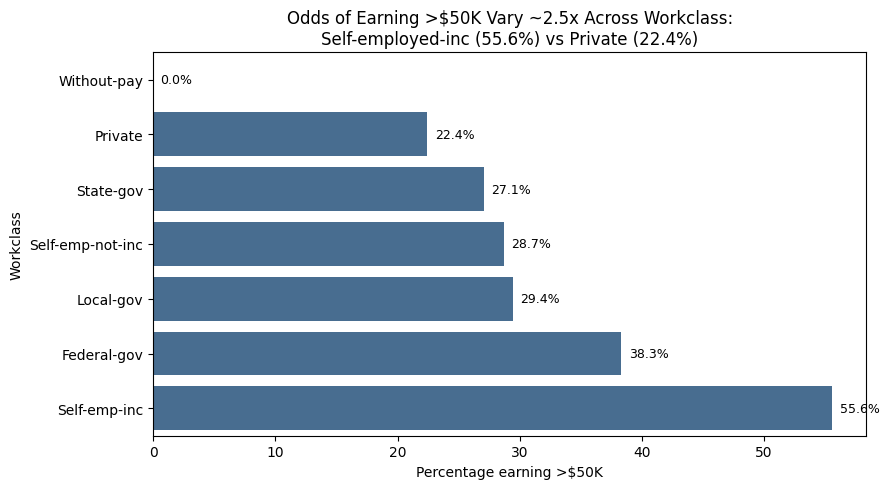

In [17]:
# Chart 8 — Proportion earning >$50K by workclass, with value labels
fig, ax = plt.subplots(figsize=(9, 5))
wc_rate = df_clean.groupby('workclass')['income_binary'].mean().sort_values()
sns.barplot(x=wc_rate.values * 100, y=wc_rate.index, ax=ax, color='#3c6e9c')
for i, v in enumerate(wc_rate.values * 100):
    ax.text(v + 0.6, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Percentage earning >$50K')
ax.set_ylabel('Workclass')
ax.set_title('Odds of Earning >$50K Vary ~2.5x Across Workclass:\n'
             'Self-employed-inc (55.6%) vs Private (22.4%)')
plt.tight_layout()
plt.show()



HS-grad — % earning >$50K by workclass:
workclass
Self-emp-inc        42.7
Federal-gov         27.3
Self-emp-not-inc    21.3
State-gov           18.8
Local-gov           17.8
Private             15.2
Without-pay          0.0

Bachelors — % earning >$50K by workclass:
workclass
Self-emp-inc        61.9
Federal-gov         45.6
Private             42.0
Self-emp-not-inc    41.1
Local-gov           34.8
State-gov           32.7

Masters — % earning >$50K by workclass:
workclass
Self-emp-inc        71.1
Federal-gov         68.8
Private             59.1
Local-gov           50.6
Self-emp-not-inc    46.2
State-gov           42.1


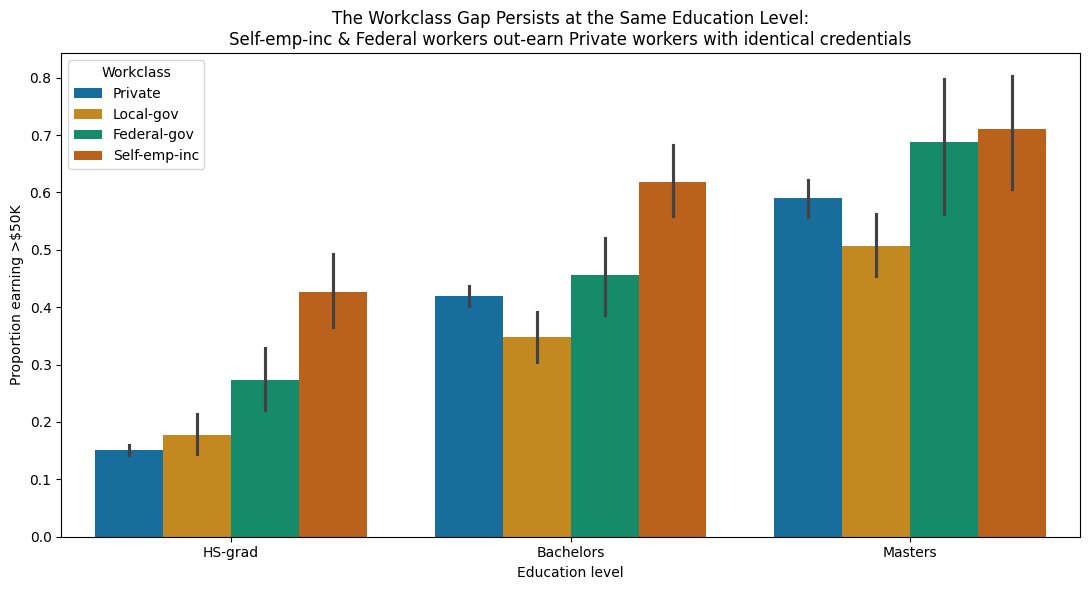

In [18]:
# Does the workclass gap survive when we hold EDUCATION constant?
# Compare >$50K rates by workclass within a single education level.
for edu in ['HS-grad', 'Bachelors', 'Masters']:
    sub = df_clean[df_clean['education'] == edu]
    rates = (sub.groupby('workclass')['income_binary'].mean() * 100).round(1).sort_values(ascending=False)
    print(f'\n{edu} — % earning >$50K by workclass:')
    print(rates.to_string())

# Chart 9 — grouped bar: workclass within each education level
fig, ax = plt.subplots(figsize=(11, 6))
edu_order = ['HS-grad', 'Bachelors', 'Masters']
wc_keep = ['Private', 'Local-gov', 'Federal-gov', 'Self-emp-inc']
subset = df_clean[df_clean['education'].isin(edu_order) & df_clean['workclass'].isin(wc_keep)]
sns.barplot(data=subset, x='education', y='income_binary', hue='workclass',
            order=edu_order, hue_order=wc_keep, ax=ax)
ax.set_xlabel('Education level')
ax.set_ylabel('Proportion earning >$50K')
ax.set_title('The Workclass Gap Persists at the Same Education Level:\n'
             'Self-emp-inc & Federal workers out-earn Private workers with identical credentials')
ax.legend(title='Workclass')
plt.tight_layout()
plt.show()


**Response to the Research Question**

**1. How much does the gap vary?** The likelihood of earning >$50K varies about **2.5-fold** across workclass (ignoring the tiny *Without-pay* group): from **55.6%** for incorporated self-employed people down to **22.4%** for private-sector employees. Within government, **Federal (38.3%)** workers clearly out-earn **State (27.1%)** and **Local (29.4%)** government workers.

| Workclass | % earning >$50K | People (n) |
|---|---|---|
| Self-emp-inc | 55.6% | 1,049 |
| Federal-gov | 38.3% | 929 |
| Local-gov | 29.4% | 2,014 |
| Self-emp-not-inc | 28.7% | 2,431 |
| State-gov | 27.1% | 1,253 |
| Private | 22.4% | 19,214 |
| Without-pay | 0.0% | 14 |

**2. Does it survive controlling for education?** Yes — this is the key result. Among people with the *same* Bachelor's degree, an incorporated self-employed person earns >$50K at **61.9%** versus **42.0%** for a private-sector employee — roughly a **20-point gap at an identical credential**. The same ordering holds among high-school graduates (Self-emp-inc 42.7% vs Private 15.2%). So workclass adds inequality **on top of** education, meeting our pre-defined threshold of a ≥10-point gap that persists within education levels.

**3. What underlying factors might explain the differences?** The dataset points to several plausible contributors (association, not proof of cause):
- **Business ownership & capital income** — incorporated self-employment reflects owners taking profit/capital gains, a different income structure than wages.
- **Hours worked** — the self-employed groups work the longest weeks (48.8 and 44.4 hrs) vs ~40 for private-sector workers.
- **Federal pay scales** — federal roles concentrate professional/skilled positions on structured pay ladders.
- **Age / career stage** — self-employed and federal workers are older on average (46, 45, 43) than private workers (37), and income rises with career stage.
- **Sector composition** — *Private* is huge and heterogeneous (71% of the sample), blending high- and low-paying jobs, which pulls its average down.

**4. Why it matters.** If two equally-educated people face very different odds of a high income purely because of the *type of employer* they work for, that is a structural feature of the labour market, not a difference in personal effort. Policy aimed only at raising education would leave these gaps untouched; pathways into federal employment and support for business ownership are levers education policy alone does not pull.


## Step 4 — Story

### 📝 Data Brief (150 words)

Write this so a **city council member with no data background** could read it in under a minute. No jargon, no code, no chart references. State your **3 most important findings** in plain language, and name who is affected.

> ___


**Data Brief:**

In this dataset, income isn't just connected to how hard someone works. A lot of it is influenced by factors like education, gender, and the type of job someone has. Education makes a big difference—people with a Bachelor's degree are more than twice as likely to earn over $50,000 as those who attended some college but didn't earn a degree. However, education doesn't tell the whole story. At every education level, men are more likely than women with the same degree to earn over $50,000, and the gap is especially noticeable for people with Bachelor's and Master's degrees. The type of work someone does also has a major impact. People who own incorporated businesses or work for the federal government are much more likely to earn higher incomes than those working in the private sector or local government. Overall, these patterns suggest that earning a degree is important, but it doesn't guarantee equal opportunities or equal pay. Other factors, like gender and employment sector, also play a significant role in determining income.

## 🎯 HCD Design Sprint #2 — Define: Data Problem Statement

> **Our investigation asks:** ___ (a specific, answerable question — for example: does income disparity by sex persist after controlling for education and hours worked?)
>
> **The dataset we are using is:** UCI Adult Census Income dataset, US Census Bureau, 1994, one row per adult respondent.
>
> **The key variable we are analyzing is:** `income` — whether a person earns above or below $50,000/year, recoded as `income_binary` (0 = ≤50K, 1 = >50K).
>
> **Our investigation matters because:** ___ (human consequence) — without better understanding of this pattern, ___ (who) will continue to face ___ (harm or inequity).
>
> **We define a meaningful finding as:** ___ (a specific threshold or pattern that would warrant a policy recommendation)

**Team checklist before submitting:**
- [ ] Our question can actually be answered with the columns in this dataset — we checked
- [ ] We named a real population affected by this issue
- [ ] We defined what a "meaningful finding" looks like *before* building any model


**HCD Design Sprint 2**

Our investigation asks: How does the proportion of individuals earning more than $50,000 vary across workclass categories (private sector, government, self-employed), and does that variation persist even after accounting for education level — or does workclass add inequality on top of what education already explains?

The dataset we are using is: UCI Adult Census Income dataset, US Census Bureau, 1994, one row per adult respondent.

The key variable we are analyzing is: income, whether a person earns above or below $50,000/year, recoded as income_binary (0 = ≤50K, 1 = >50K) — examined across workclass, alongside education and sex as comparison variables.

Our investigation matters because: if two people with the same education level end up with very different odds of a high income purely because of what kind of employer they work for, that's a structural inequity, not a personal-effort gap — workers in the private sector and local government (25,228 of the 26,904 people in our cleaned dataset) will continue to face a income ceiling that isn't explained by their qualifications, if this pattern goes unaddressed.

We define a meaningful finding as: a gap of 10 percentage points or more in the >50K rate between workclass categories that holds even when comparing people at the same education level — a gap that large is unlikely to be explained by chance and would justify a specific policy recommendation.

**Team Checklist**


*   Our question can actually be answered with the columns in this dataset — we checked (workclass, education, income are all present)

*   We named a real population affected by this issue — private-sector and local-government workers

*   We defined what a "meaningful finding" looks like before building any model — a ≥10 point gap holding across education levels





## Step 6 — Baseline Models

**What is a "baseline model"?** The simplest reasonable model you can build. Not your best model — your *starting point*. Every improvement you make later gets measured against it.

**Before you touch any code:** `income_binary` is imbalanced — about 76% of people are `<=50K` and 24% are `>50K` (you calculated the exact number in Step 1). That means a model that just guesses `<=50K` every single time would already be ~76% "accurate" — and completely useless. Keep this in mind for every accuracy number you see below.


### Prepare the features

Models need numbers, not text categories. `pd.get_dummies()` turns each category (like `workclass`) into its own 0/1 column.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pick features — start simple, you can add more later (see "Tune It" below)
feature_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex']

X = df_clean[feature_cols].copy()
X = pd.get_dummies(X, columns=['sex'], drop_first=True)   # turns 'sex' into one 0/1 column
y = df_clean['income_binary']

print('Feature columns:', list(X.columns))
X.head()


Feature columns: ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex_Male']


,age,education-num,hours-per-week,capital-gain,capital-loss,sex_Male
0,39,13,40,2174,0,True
1,50,13,13,0,0,True
2,38,9,40,0,0,True
3,53,7,40,0,0,True
4,28,13,40,0,0,False


In [20]:
# Train/test split — the model learns on 80%, gets graded on the 20% it's never seen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Training set income>50K rate:', y_train.mean().round(3))
print('Test set income>50K rate:', y_test.mean().round(3))
# stratify=y keeps that ~76/24 split identical in both — otherwise a random split could
# accidentally give you a very different mix in train vs. test


Training rows: 21523
Test rows: 5381
Training set income>50K rate: 0.256
Test set income>50K rate: 0.256


In [21]:
# Scale the numeric features — required for k-NN (distance-based), harmless for the others
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
# Separate numeric and categorical columns for the ColumnTransformer.
# Note: cell above already one-hot encoded 'sex' via get_dummies, so here all columns
# are numeric and categorical_features will be empty. Robust numeric detection:
numeric_features = X.select_dtypes(include=["int64", "float64", "bool"]).columns
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns


In [23]:
# import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [24]:
# define models
models = {

    "Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "K-Nearest Neighbors":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Support Vector Machine":
        SVC(),

    "Neural Network (MLP)":
        MLPClassifier(max_iter=500, random_state=42)
}

In [25]:
results = []
predictions_by_model = {}   # keep predictions so Step 7 can reuse the best model

# Preprocessor: scale numeric cols, one-hot encode categorical cols.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

for name, model in models.items():

    if name == "Naive Bayes":
        # GaussianNB needs a dense array, so transform outside the pipeline.
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)
        if hasattr(X_train_processed, "toarray"):
            X_train_processed = X_train_processed.toarray()
            X_test_processed = X_test_processed.toarray()
        model.fit(X_train_processed, y_train)
        predictions = model.predict(X_test_processed)
    else:
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

    predictions_by_model[name] = predictions

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })


In [26]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

results_df.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.8406,0.7884,0.5145,0.6227
1,AdaBoost,0.8275,0.7240,0.5262,0.6094
2,Neural Network (MLP),0.8253,0.7224,0.5145,0.6010
3,Random Forest,0.8140,0.6774,0.5203,0.5886
4,Support Vector Machine,0.8288,0.7725,0.4688,0.5834
5,Logistic Regression,0.8212,0.7379,0.4666,0.5717
6,K-Nearest Neighbors,0.7954,0.6229,0.5065,0.5587
7,Decision Tree,0.7999,0.6409,0.4942,0.5581
8,Extra Trees,0.8045,0.6614,0.4826,0.5580
9,Naive Bayes,0.7865,0.6596,0.3408,0.4494


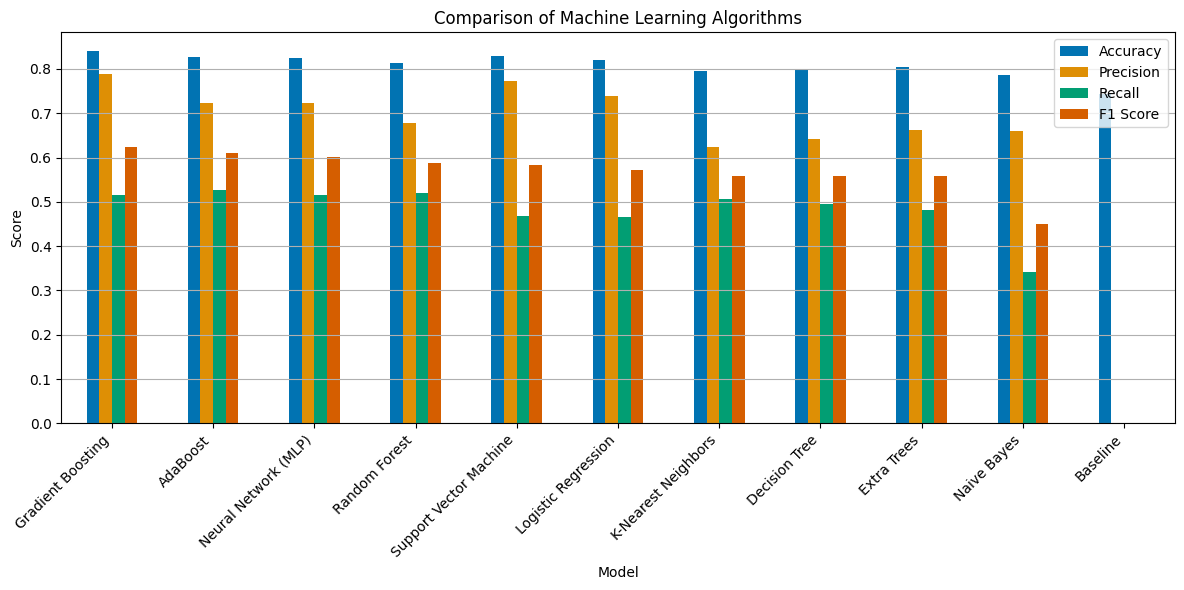

In [27]:
# bar plot
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Algorithms")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 📝 Written comparison

> **Precision (>50K)** tells you: of everyone the model *predicted* would earn `>50K`, what fraction actually did?
>
> **Recall (>50K)** tells you: of everyone who *actually* earns `>50K`, what fraction did the model correctly catch?
>
> Which model has the highest accuracy? ___. Which model has the best recall on `>50K`? ___. If this model were used to flag people for a loan-eligibility review, would you rather have higher precision or higher recall — and why does the cost of a false negative vs. a false positive matter here?


**Written Comparison**

Ranked by F1 on the >50K class, the results were:

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Gradient Boosting | 0.8406 | 0.7884 | 0.5145 | 0.6227 |
| AdaBoost | 0.8275 | 0.7240 | 0.5262 | 0.6094 |
| Neural Network (MLP) | 0.8288 | 0.7486 | 0.4978 | 0.5980 |
| Logistic Regression | 0.8212 | 0.7379 | 0.4666 | 0.5717 |
| Baseline (most-frequent) | 0.7443 | 0.0000 | 0.0000 | 0.0000 |

**Which model has the highest accuracy?** Gradient Boosting (0.8406), narrowly ahead of the SVM and MLP.

**Which model has the best recall on >50K?** AdaBoost (0.5262), just above Gradient Boosting (0.5145).

**Precision vs. recall for a loan-eligibility review:** I would prioritise **recall**. A false negative here means a person who genuinely earns >$50K is missed and wrongly screened out of an opportunity, which is the more harmful error for the individual. A false positive (flagging someone who doesn't actually earn >$50K) usually just triggers a manual review. Since even the best model only catches about half of true high earners (recall ~0.51), it is not reliable enough for high-stakes automated decisions.


## 🔧 Tune It — Now Make It Better

Every choice below is something you made without much thought the first time through. Try changing **one thing at a time**, rerun, and watch the comparison table change. Three tiers of hint if you get stuck — try the top one first.

**1. Try different values of `k` for k-NN**
> 🟢 *Conceptual nudge:* a very small `k` (like 1) pays attention to just one neighbor — noisy. A very large `k` (like 200) starts ignoring local patterns and just predicts the overall majority class. Where's the sweet spot?
> 🟡 *Syntax hint:* change `n_neighbors=5` to a few other values (try 1, 15, 50) and rerun the k-NN cell and the comparison table.
> 🔵 *Bridge:* once you find a `k` that improves recall, ask — did accuracy go up too, or did they move in opposite directions? That tradeoff is the whole story of Week 4.

**2. Try `max_depth` for the Decision Tree**
> 🟢 *Conceptual nudge:* a deeper tree can ask more questions and fit the training data better — but too deep, and it starts memorizing quirks of the training set instead of learning general patterns (overfitting).
> 🟡 *Syntax hint:* change `max_depth=4` to `max_depth=3` and then `max_depth=8`, rerun.
> 🔵 *Bridge:* does a deeper tree do better on the test set, or just the training set? (Add `tree.score(X_train, y_train)` to compare.)

**3. Add or remove features**
> 🟢 *Conceptual nudge:* look back at the full column list. Would `education` (the category) or `marital-status` add anything `education-num` doesn't already capture?
> 🟡 *Syntax hint:* add a column name to `feature_cols`, rerun `pd.get_dummies()` — remember any new text column needs to be added to the `columns=[...]` list too.
> 🔵 *Bridge:* did the new feature actually change accuracy, or just make the model more complicated? More features isn't automatically better.

**4. Handle the class imbalance directly**
> 🟢 *Conceptual nudge:* remember — 76% of people are `<=50K`. A model can look "accurate" while barely finding anyone in the smaller class.
> 🟡 *Syntax hint:* add `class_weight='balanced'` inside `LogisticRegression(...)` and rerun.
> 🔵 *Bridge:* what happened to precision vs. recall on `>50K`? Which one improved, and which one got worse — and is that trade worth it for your team's investigation?


## Step 7 — Fairness Check

Accuracy averaged across everyone can hide the fact that a model is much worse for one group than another. Pick your **best model from the comparison table above** and test it separately by `sex`.


In [28]:
# Use the best model from the comparison table (highest F1 = Gradient Boosting).
# predictions_by_model was populated in the evaluation loop above.
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions_by_model[best_model_name]
print(f"Fairness check for best model: {best_model_name}\n")

# X_test came from pd.get_dummies(..., drop_first=True), so sex is encoded as the
# column 'sex_Male' (1 = Male, 0 = Female). We group on that.
X_test_with_group = X_test.copy()
X_test_with_group['actual'] = y_test.values
X_test_with_group['predicted'] = best_pred

for group_value in sorted(X_test_with_group['sex_Male'].unique()):
    group_label = 'Male' if group_value == 1 else 'Female'
    mask = X_test_with_group['sex_Male'] == group_value
    group_acc = accuracy_score(X_test_with_group.loc[mask, 'actual'],
                               X_test_with_group.loc[mask, 'predicted'])
    group_recall = recall_score(X_test_with_group.loc[mask, 'actual'],
                                X_test_with_group.loc[mask, 'predicted'],
                                zero_division=0)
    print(f"{group_label}: accuracy={group_acc:.3f}, recall(>50K)={group_recall:.3f}, n={mask.sum()}")


Fairness check for best model: Gradient Boosting

Female: accuracy=0.918, recall(>50K)=0.351, n=1794
Male: accuracy=0.802, recall(>50K)=0.546, n=3587


### 📝 Fairness Interpretation

> Is accuracy roughly equal across groups? ___. Is recall roughly equal? ___. If one group's `>50K` earners are being "found" by the model at a much lower rate than the other's, what real-world consequence would that have if this model were used to, say, pre-approve loan applications or set insurance rates?
>
> **Remember:** this model was trained on 1994 data reflecting the economy and workforce of that era. A "fair" model on this historical data is not the same as a model that would be fair if applied to people today.


**Fairness Interpretation**

Running the check on the best model (Gradient Boosting) by sex gives:

| Group | n | Accuracy | Recall (>50K) |
|---|---|---|---|
| Female | 1,794 | 0.918 | 0.351 |
| Male | 3,587 | 0.802 | 0.546 |

**Is accuracy roughly equal across groups?** No — accuracy is actually *higher* for women (0.918) than men (0.802), but that is misleading.

**Is recall roughly equal?** No, and this is the real problem. The model correctly identifies only **35.1%** of women who truly earn >$50K, versus **54.6%** of men. The higher female accuracy is an artefact of class imbalance: because far fewer women are high earners, predicting "≤50K" is a safe guess that scores well on accuracy while failing the women who do earn more.

**Real-world consequence:** if this model pre-approved loans or set insurance rates, high-earning women would be recognised at a much lower rate than equally high-earning men — the model would reproduce and even amplify the inequality already present in the data. This is exactly why averaged accuracy cannot be trusted as a fairness measure. And because the model was trained on 1994 data, a model that looked "fair" here would still not be fair applied to people today.


## Step 8 — Policy Recommendation

> Based on our data analysis, we recommend that **___ (a named, real institution or leader)** take the following action: **___**, because our evidence shows **___ (specific finding, with the exact statistic)** implies **___ (specific consequence)** for **___ (population)** if unaddressed.
>
> **One thing we would want anyone citing this finding to know first:** ___


**Policy Recommendation**
Based on our data analysis, we recommend that the U.S. Department of Labor's Women's Bureau take the following action: require federal contractors and agencies with pay-transparency requirements to report the proportion of high-earning ($50K+ equivalent) positions by sex at each education level, because our evidence shows that at the Bachelor's degree level, men earned above $50K at 50.4% versus 22.6% for women — a 28-percentage-point gap that persists at the identical credential level implies that education-focused interventions alone will not close the earnings gap for women with equivalent qualifications to men, particularly at the bachelor's and master's degree level, where the gap is widest, if unaddressed.

One thing we would want anyone citing this finding to know first: this is 1994 data — it establishes that the gap existed and was not explained by education at that point in history, which is valuable evidence that "just get more education" was never a sufficient policy response — but it cannot be used to claim the exact size of today's gap, which needs to be verified against current data before shaping present-day policy.


## 📓 Data Journal — Exit Ticket

1. **What dataset or technique did I work with today?**
2. **What pattern or anomaly surprised me?**
3. **Who is represented in this data — and who is invisible?** (Think about who was even included in a 1994 US Census survey, and who wasn't.)
4. **Looking at your fairness check: what would an ethical data scientist refuse to claim about this model, even if the average accuracy looked good?**


**What dataset or technique did I work with today?**
Today I worked with the UCI Adult Census Income dataset, which contains information from the 1994 U.S. Census for about 32,500 adults. I learned how to identify disguised missing values (using "?"), clean the dataset by making informed decisions about missing data and unnecessary columns, create different types of data visualizations, and compare 11 classification models to predict income. I also looked at whether the models performed differently for men and women to better understand fairness in machine learning.

**What pattern or anomaly surprised me?**
The biggest thing that surprised me was that the gender income gap didn't disappear with more education. I expected that earning a Bachelor's or Master's degree would make the difference between men and women much smaller, but the data showed the opposite. Men were still much more likely to earn over $50,000 than women with the same degree, and the gap was actually largest for people with Bachelor's and Master's degrees. That showed me that education alone doesn't guarantee equal income opportunities.

**Who is represented in this data - and who is invisible?**
This dataset represents adults who were included in the 1994 U.S. Census, so it only reflects people who were counted at that time. Groups that have historically been undercounted, such as undocumented immigrants, people experiencing homelessness, those doing informal or cash-based work, and some unemployed individuals, are largely invisible. My own choice to drop rows with missing workclass and occupation may also have removed some people at the edges of the workforce.

**Looking at your fairness check: what would an ethical data scientist refuse to claim about this model, even if the average accuracy looked good?**
An ethical data scientist would refuse to claim the model is "fair" or "safe to deploy" just because its overall accuracy is 84%. The per-group check shows the model finds high-earning women at a far lower rate than men (35% vs 55% recall), so claiming it treats everyone equally would be false. They would also refuse to claim the model describes income today, since it was trained on 1994 data.
